# Read Data

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
accounts = pd.read_csv("moneycraft_accounts.csv")
closure = pd.read_csv("moneycraft_closure_reasons.csv")
marketing = pd.read_csv("moneycraft_marketing_spend.csv")
scv = pd.read_csv("moneycraft_scv.csv")

# Preprocessing

## Accounts

In [6]:
accounts.shape

(179018, 8)

In [7]:
accounts.isna().sum()

customer_id            0
month                  0
acquisition_channel    0
region                 0
age_band               0
account_tier           0
monthly_fee            0
joined_on_promo        0
dtype: int64

### Customer ID

Customer ID has a datatype of int64 (which is desired), so there isn't a need to force it into such a form.

In [9]:
missing_customer_ids = accounts["customer_id"].isnull().sum()
print(f"Missing Customer IDs: {missing_customer_ids}")

Missing Customer IDs: 0


In [10]:
duplicated_customer_ids = accounts["customer_id"].duplicated().sum()
print(f"No. duplicated IDs : {duplicated_customer_ids}")

No. duplicated IDs : 163286


How many unique ids are there?

In [12]:
print(f"There are {accounts["customer_id"].nunique()} unique customers")

There are 15732 unique customers


Duplicate ids exist as customers pay on a monthly basis. To really check for duplicates per month for each customer, one subscription per customer per month

In [14]:
monthly_duplicates = accounts.duplicated(subset = ["customer_id", "month"]).sum()
print(f"Duplicate Customer IDs within the same month: {monthly_duplicates}")

Duplicate Customer IDs within the same month: 0


In [16]:
customer_id_validity = accounts[accounts["customer_id"] <= 0].sum().sum()
print(f"No. customer ids within an unvalid range: {customer_id_validity}")

No. customer ids within an unvalid range: 0


### Month

In [19]:
print(accounts.month.min())
print(accounts.month.max())
accounts["month"].value_counts()

2022-01
2024-12


month
2024-12    9775
2024-11    9501
2024-10    9147
2024-09    8865
2024-08    8604
2024-07    8319
2024-06    8083
2024-05    7794
2024-04    7480
2024-03    7196
2024-02    6974
2024-01    6689
2023-12    6372
2023-11    6081
2023-10    5843
2023-09    5569
2023-08    5350
2023-07    5104
2023-06    4862
2023-05    4588
2023-04    4354
2023-03    4055
2023-02    3773
2023-01    3543
2022-12    3260
2022-11    2980
2022-10    2701
2022-09    2443
2022-08    2165
2022-07    1862
2022-06    1591
2022-05    1345
2022-04    1086
2022-03     824
2022-02     560
2022-01     280
Name: count, dtype: int64

The months are consistent and complete, there are no abnormalities in the temporal data provided.

In [21]:
# Change month to date
accounts['month'] = pd.PeriodIndex(accounts['month'], freq='M')
accounts['month'].head()

0    2022-01
1    2022-01
2    2022-01
3    2022-01
4    2022-01
Name: month, dtype: period[M]

How many unique channels are there?

In [23]:
print(f"There are {accounts["acquisition_channel"].nunique()} unique channels")

There are 6 unique channels


In [25]:
print(accounts["acquisition_channel"].value_counts())

acquisition_channel
Online             43906
Comparison Site    42794
Branch             33277
Referral           25160
Outbound           20298
Broker/IFA         13583
Name: count, dtype: int64


In [27]:
print(f"There are {accounts["acquisition_channel"].isna().sum()} nulls in the channel columns")

There are 0 nulls in the channel columns


### Region

In [29]:
print(f"There are {accounts['region'].nunique()} regions")

There are 6 regions


In [31]:
print(accounts["region"].value_counts())

region
London        42874
North         36890
South East    36613
Midlands      31012
Scotland      17852
Wales & NI    13777
Name: count, dtype: int64


### Age Bands

In [33]:
print(f"There are {accounts["age_band"].nunique()} age bands")

There are 6 age bands


In [35]:
print(accounts["age_band"].value_counts())

age_band
25-34    45265
35-44    44012
45-54    32397
55-64    22361
18-24    20988
65+      13995
Name: count, dtype: int64


The dataset is heavily comminated by 25-44 year olds.

### Accounts Tier

In [37]:
print(f"There are {accounts["account_tier"].nunique()} account tiers")

There are 4 account tiers


In [39]:
print(accounts["account_tier"].value_counts())

account_tier
Silver      57256
Gold        54411
Classic     35795
Platinum    31556
Name: count, dtype: int64


In [41]:
print(accounts["account_tier"].unique().tolist())

['Classic', 'Silver', 'Platinum', 'Gold']


### Monthly Fee ?!?!?!!?

In [57]:
accounts["monthly_fee"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 179018 entries, 0 to 179017
Series name: monthly_fee
Non-Null Count   Dtype
--------------   -----
179018 non-null  int64
dtypes: int64(1)
memory usage: 1.4 MB


In [54]:
print(f"There are {accounts["monthly_fee"].nunique()} fees")

There are 4 fees


In [55]:
df_fee_table = pd.pivot_table(data = accounts, values = "monthly_fee", index = "account_tier")
df_fee_table.sort_values("monthly_fee", ascending = True, inplace = True)
df_fee_table["monthly_fee"] = df_fee_table["monthly_fee"].round(2)

In [56]:
df_fee_table

,monthly_fee
account_tier,
Classic,0.00
Silver,8.82
Gold,16.03
Platinum,25.75


### Joined on a promotional basis

In [48]:
print(accounts["joined_on_promo"].nunique())

2


In [50]:
print(accounts["joined_on_promo"].value_counts())

joined_on_promo
False    115271
True      63747
Name: count, dtype: int64


## Closure Reasons ?!?!

In [51]:
closure.duplicated().sum()

np.int64(0)

In [82]:
# Reasons why people left and how it could help with our recommendations
closure['reason_code'].value_counts()

reason_code
Fees too high         1268
Poor service           887
Unknown                635
Switched provider      623
Unhappy with perks     254
Moved abroad           210
Bereavement            146
Name: count, dtype: int64

## Marketing ?!?!

## Create SCV

Now lets create a single customer view of our data, rather than monthly. We define most of our desired columns below, apart from churned and ever_paid.

In [79]:
grouped = accounts.groupby('customer_id')

signup_month = grouped['month'].min()   # First month
last_active = grouped['month'].max()   # last month
tenure_months = grouped['month'].count()    # total tenure
channel = grouped['acquisition_channel'].first()
age_band = grouped['age_band'].first()
region = grouped['region'].first()
first_plan = grouped['account_tier'].first()
last_plan = grouped['account_tier'].last()
total_revenue = grouped['monthly_fee'].sum()
max_paid = grouped['monthly_fee'].max()
joined_on_promo = grouped['joined_on_promo'].first()

Then create our SCV dataframe, add the remaining two columns and merge with closure to obtain a reason column.

In [92]:
scv = pd.DataFrame({
    'signup_month': signup_month,
   'last_active': last_active,
    'tenure_months': tenure_months,
    'channel': channel,
    'age_band': age_band,
    'region': region,
    'first_plan': first_plan,
    'last_plan': last_plan,
    'total_revenue': total_revenue,
    'max_paid': max_paid,
    'joined_on_promo': joined_on_promo
})

scv['ever_paid'] = scv0['max_paid'] > 0
scv['churned'] = scv0['last_active'] < accounts['month'].max()

# create index for closure and merge map reasons onto scv
closure_indexed = closure.set_index('customer_id')
scv['reason_code'] = (scv.index).map(closure_indexed['reason_code'])

scv.head()

,signup_month,last_active,tenure_months,channel,age_band,region,first_plan,last_plan,total_revenue,max_paid,joined_on_promo,ever_paid,churned,reason_code
customer_id,,,,,,,,,,,,,,
1,2022-01,2022-06,6,Comparison Site,25-34,Scotland,Classic,Classic,0,0,False,False,True,Switched provider
2,2022-01,2024-12,36,Online,55-64,London,Silver,Platinum,595,28,False,True,False,NaN
3,2022-01,2024-12,36,Branch,25-34,South East,Platinum,Platinum,848,28,False,True,False,NaN
4,2022-01,2024-12,36,Referral,25-34,London,Silver,Silver,330,11,True,True,False,NaN
5,2022-01,2022-10,10,Comparison Site,35-44,South East,Silver,Classic,33,11,False,True,True,Bereavement


Can create a new csv containing this table which can then be called upon quickly.

In [95]:
# scv.to_csv("moneycraft_scv.csv", index=False)

# Analysis

## Retention Analysis

### Retention curve (all customers)

In [85]:
# Retention curve
max_t = int(scv['tenure_months'].max())
# max_time = max_t + 1

# For each month
retention = [(scv['tenure_months']> t).mean() for t in range(max_t)]

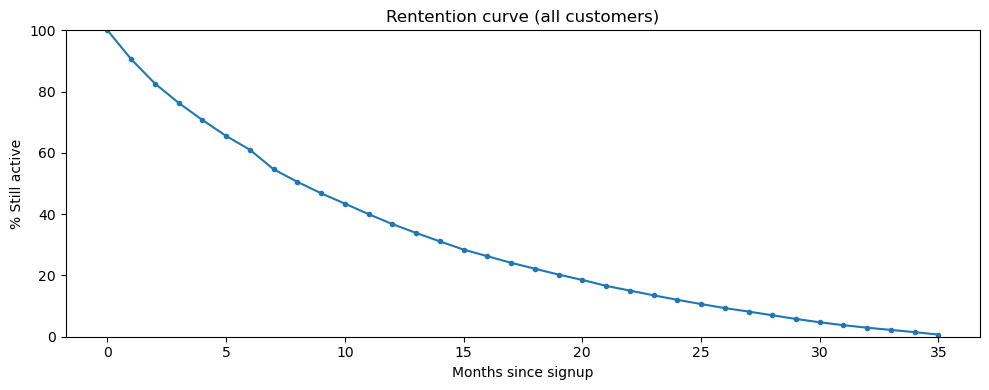

In [86]:
plt.figure(figsize=(10, 4))
plt.plot(range(max_t), [r * 100 for r in retention], marker='.')
plt.title('Rentention curve (all customers)')
plt.xlabel('Months since signup')
plt.ylabel('% Still active')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

This plot shows the percentage of customers who are still signed up after x months.

It depicts a rough exponential decay as we would expect, however the smooth exponential decay trend is broken at 6-months, where we see a sharp decrease in the number of customers still signed up. This time period coincides with the length of our promotional offers.

**Insight:** 

Some customers are leaving when the promo runs out, either because they never had any intention of staying subscribed (promo-hunters), or were not satisfied with the service enough to stay subscribed.

### Retention curve by channel

In [115]:
# Calculate the customer retention rate over time, segmented by the acquisition channel.

# Get the maximum tenure observed in the data - longest period a customer has been active in months
max_tenure = scv['tenure_months'].max()

# Initialize an empty DataFrame to store retention rates by channel - months since signup from 1 to the
# max (plus one because we are using 'range')
retention_by_channel = pd.DataFrame(index=range(1, max_tenure + 1))

# Loop through each channel to create a group containing all customers acquired through that channel
for channel_name, group in scv.groupby('channel'):
    cohort_size = len(group)  # The number of customers in the current channel
    if cohort_size == 0:
        retention_by_channel[channel_name] = np.nan
        continue

    channel_retention = []
    for t in range(1, max_tenure + 1):
        num_retained = (group['tenure_months'] >= t).sum()
        channel_retention.append((num_retained / cohort_size) * 100)
    retention_by_channel[channel_name] = channel_retention

display(retention_by_channel.head().round(2))

,Branch,Broker/IFA,Comparison Site,Online,Outbound,Referral
1,100.00,100.00,100.00,100.00,100.00,100.00
2,92.62,95.10,87.78,91.43,88.43,92.85
3,86.66,89.99,77.73,83.82,79.87,85.92
4,81.78,84.98,70.00,77.77,72.48,81.01
5,76.30,80.49,63.53,72.66,65.55,77.28


In [116]:
# Calculate the monthly drop in retention for each channel
retention_drops = retention_by_channel.diff(periods=-1, axis=0) * -1 # Difference with next month, then make positive for drops

# Or, to show the actual percentage drop from one month to the next:
monthly_retention_change = retention_by_channel.diff() # Difference from previous month

# Find the month with the sharpest drop for each channel
# We're looking for the largest negative change, so min() on diff()
sharpest_drops_month_and_value = monthly_retention_change.min()

print("Monthly Percentage Change in Retention (Negative values indicate a drop):")
display(monthly_retention_change.head().round(2))

print("\nSharpest Drop (Largest negative change) and the month it occurred:")
for channel in monthly_retention_change.columns:
    min_drop = monthly_retention_change[channel].min()
    month_of_sharpest_drop = monthly_retention_change[channel].idxmin()
    print(f"  {channel}: Month {month_of_sharpest_drop}, Drop: {min_drop:.2f}%")

Monthly Percentage Change in Retention (Negative values indicate a drop):


,Branch,Broker/IFA,Comparison Site,Online,Outbound,Referral
1,NaN,NaN,NaN,NaN,NaN,NaN
2,-7.38,-4.90,-12.22,-8.57,-11.57,-7.15
3,-5.97,-5.11,-10.06,-7.61,-8.56,-6.93
4,-4.88,-5.01,-7.72,-6.05,-7.39,-4.91
5,-5.48,-4.49,-6.48,-5.12,-6.93,-3.73



Sharpest Drop (Largest negative change) and the month it occurred:
  Branch: Month 2, Drop: -7.38%
  Broker/IFA: Month 6, Drop: -5.52%
  Comparison Site: Month 2, Drop: -12.22%
  Online: Month 2, Drop: -8.57%
  Outbound: Month 2, Drop: -11.57%
  Referral: Month 2, Drop: -7.15%


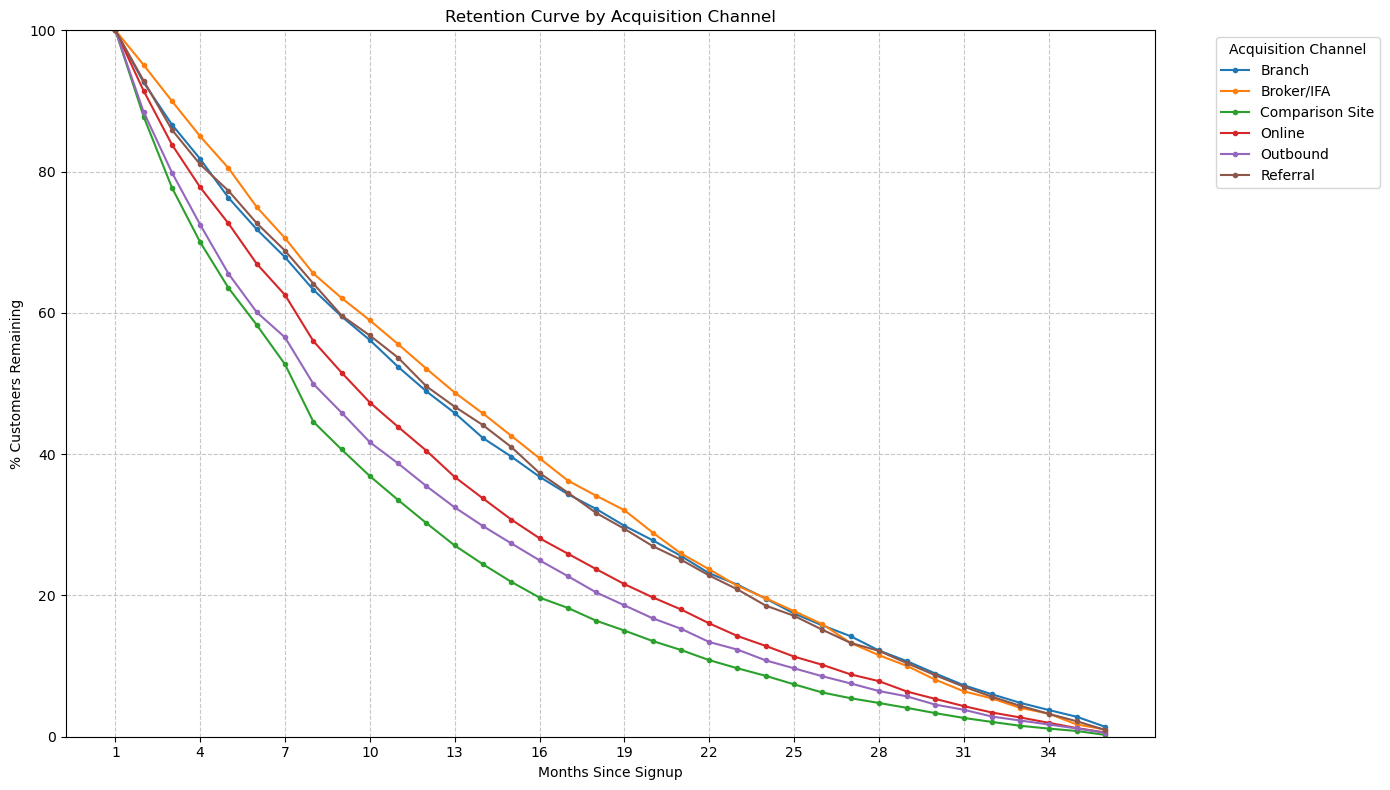

In [118]:
plt.figure(figsize=(14, 8))
for column in retention_by_channel.columns:
    plt.plot(retention_by_channel.index, retention_by_channel[column], label=column, marker='.')

plt.title('Retention Curve by Acquisition Channel')
plt.xlabel('Months Since Signup')
plt.ylabel('% Customers Remaining')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Acquisition Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 100)
plt.xticks(np.arange(1, max_tenure + 1, 3)) # Show x-ticks every 3 months for readability
plt.tight_layout()
plt.show()

### Retention curve by Tier (first plan)

In [111]:
# Initialize an empty DataFrame to store retention rates by account tier
retention_by_tier = pd.DataFrame(index=range(1, max_tenure + 1))

# Iterate through each unique account tier
for tier_name, group in scv.groupby('first_plan'):
    cohort_size = len(group)
    if cohort_size == 0:
        retention_by_tier[tier_name] = np.nan
        continue

    tier_retention = []
    for t in range(1, max_tenure + 1):
        num_retained = (group['tenure_months'] >= t).sum()
        tier_retention.append((num_retained / cohort_size) * 100)
    retention_by_tier[tier_name] = tier_retention

display(retention_by_tier.head().round(2))

,Classic,Gold,Platinum,Silver
1,100.00,100.00,100.00,100.00
2,86.41,93.45,93.55,91.21
3,75.69,87.53,88.03,83.46
4,67.50,82.38,83.01,77.52
5,60.51,77.83,78.76,71.97


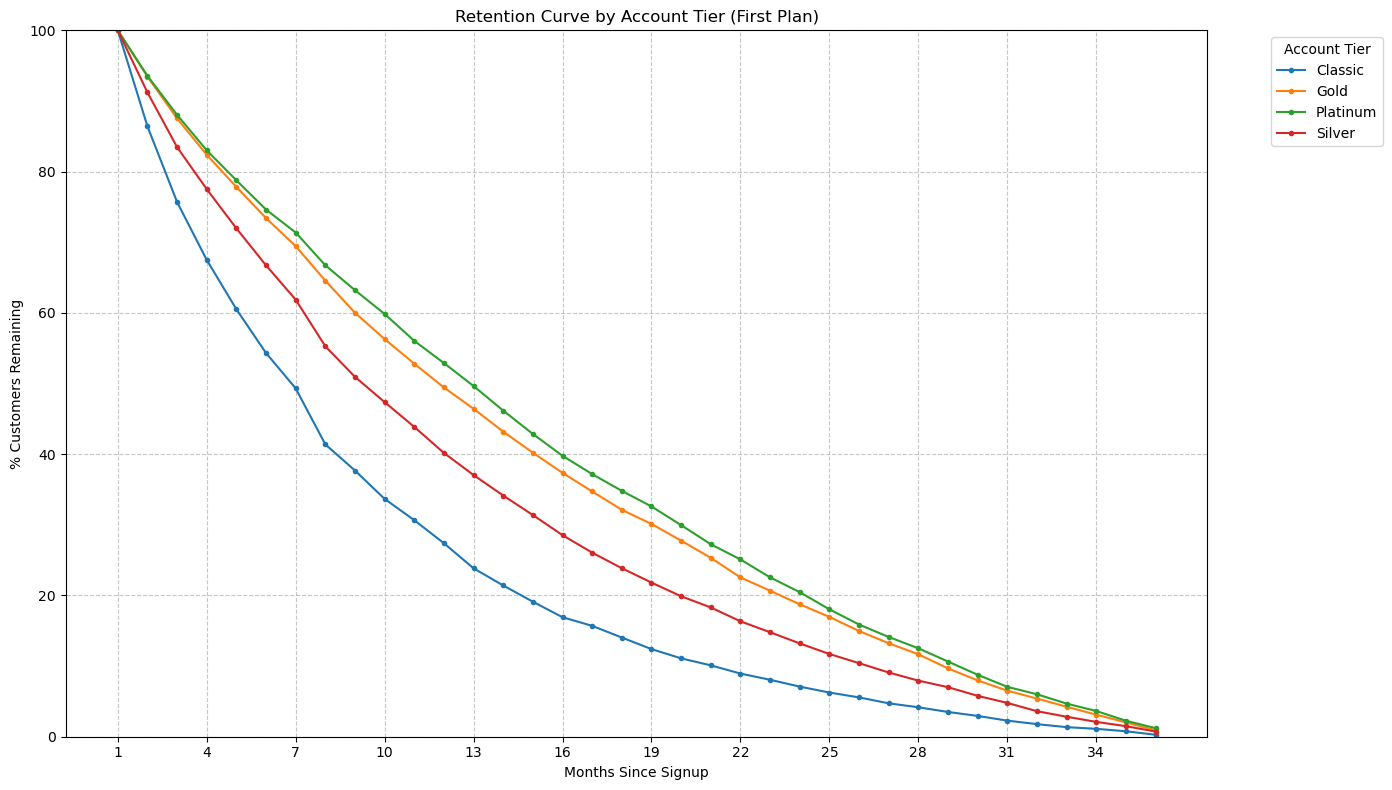

In [119]:
plt.figure(figsize=(14, 8))
for column in retention_by_tier.columns:
    plt.plot(retention_by_tier.index, retention_by_tier[column], label=column, marker='.')

plt.title('Retention Curve by Account Tier (First Plan)')
plt.xlabel('Months Since Signup')
plt.ylabel('% Customers Remaining')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Account Tier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 100)
plt.xticks(np.arange(1, max_tenure + 1, 3)) # Show x-ticks every 3 months for readability
plt.tight_layout()
plt.show()

### Retention by cohort

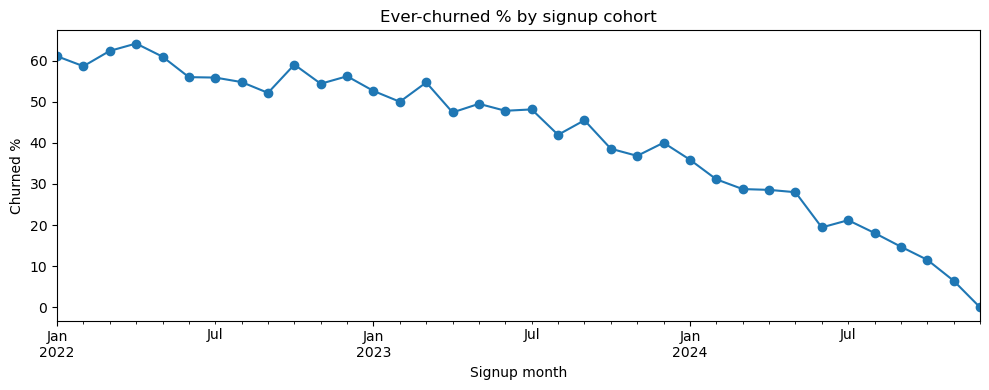

In [113]:
# Cohorts
cohort_churn = scv.groupby('signup_month')['churned'].mean() * 100

plt.figure(figsize=(10, 4))
cohort_churn.plot(marker='o')
plt.title('Ever-churned % by signup cohort')
plt.xlabel('Signup month')
plt.ylabel('Churned %')
plt.tight_layout()
plt.show()

This plot shows the percentage of customers that have churned by month of sign up. We see more recent cohorts have churned less, as they have not been subscribed for as long. 

We also see some spikes, which indicates cohorts that have churned more than expected, possibly due to a promo being live during this month, or budget allocating more money to channels that attract low-commitment customers. Could look into further!

## Tenure Analysis

In [120]:
# Finding the average tenure (months active) across the various channels and packages (account tiers).
avg_tenure_per_channel = scv.groupby(['channel', 'first_plan'])['tenure_months'].mean().round(2)
display(avg_tenure_per_channel)

channel          first_plan
Branch           Classic       11.02
                 Gold          14.09
                 Platinum      14.59
                 Silver        12.93
Broker/IFA       Classic        9.24
                 Gold          14.11
                 Platinum      14.54
                 Silver        13.34
Comparison Site  Classic        7.74
                 Gold          11.94
                 Platinum      12.59
                 Silver        10.18
Online           Classic        9.34
                 Gold          12.69
                 Platinum      13.92
                 Silver        11.75
Outbound         Classic        8.26
                 Gold          13.02
                 Platinum      11.00
                 Silver        10.84
Referral         Classic       11.03
                 Gold          14.53
                 Platinum      14.10
                 Silver        12.84
Name: tenure_months, dtype: float64

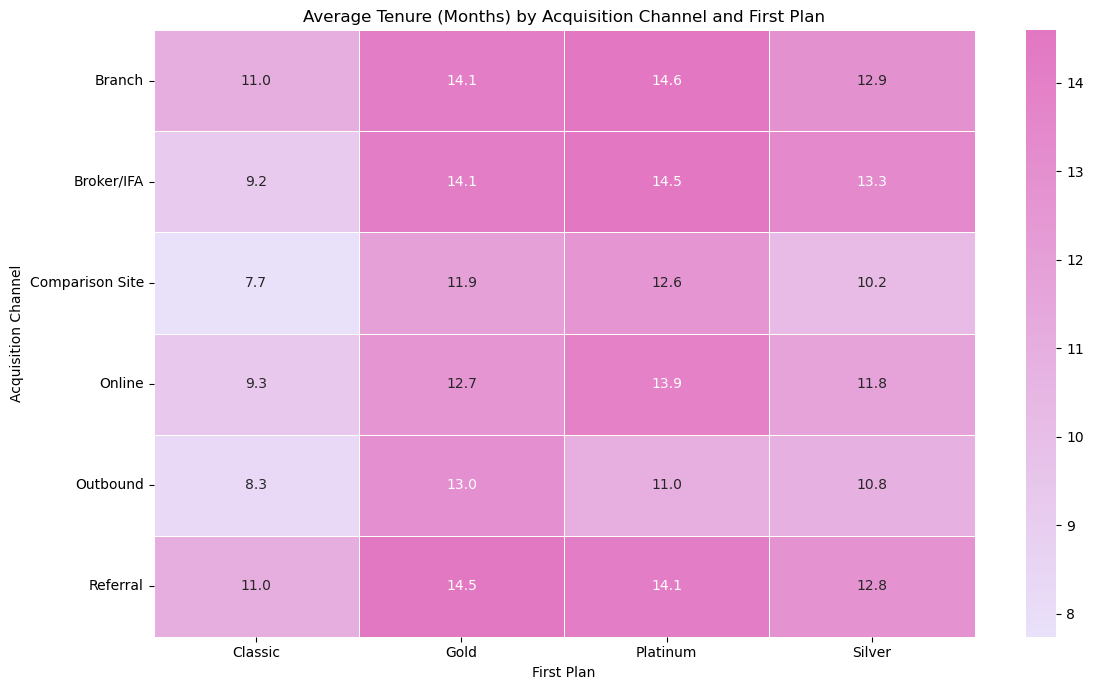

In [99]:
# Reshape the data for a heatmap
avg_tenure_pivot = avg_tenure_per_channel.unstack()

# Define your custom colors (reusing the list from previous interaction)
custom_colors = ['#E9E1FA', '#e377c2']
# custom_colors = ['#8B5CF6', '#211A3B', '#2DD4BF', '#E9E1FA', '#F6F4FC', '#8c564b', '#e377c2']

# Create a custom colormap from the list of colors
from matplotlib.colors import LinearSegmentedColormap
cmap_custom = LinearSegmentedColormap.from_list("custom_cmap", custom_colors)

plt.figure(figsize=(12, 7))
sns.heatmap(avg_tenure_pivot, annot=True, fmt=".1f", cmap=cmap_custom, linewidths=.5)
plt.title('Average Tenure (Months) by Acquisition Channel and First Plan')
plt.xlabel('First Plan')
plt.ylabel('Acquisition Channel')
plt.tight_layout()
plt.show()

Can see Classic members have the shortest average tenure. Also customers who join through Comparison site and Outbound have shortest average tenure

## Reason Code Distribution

In [101]:
reason_code_distribution = scv.groupby(['channel', 'reason_code']).size().unstack(fill_value=0)
reason_code_distribution_percent = reason_code_distribution.apply(lambda x: (x / x.sum()) * 100, axis=1).round(2)
display(reason_code_distribution_percent)

reason_code,Bereavement,Fees too high,Moved abroad,Poor service,Switched provider,Unhappy with perks,Unknown
channel,,,,,,,
Branch,4.17,14.58,6.48,30.09,13.43,14.12,17.13
Broker/IFA,3.45,11.03,6.90,27.59,17.24,15.17,18.62
Comparison Site,2.89,46.82,3.73,15.61,17.47,2.18,11.30
Online,3.48,24.43,6.55,25.62,14.30,6.65,18.97
Outbound,4.66,26.42,4.84,24.53,14.16,5.01,20.38
Referral,5.28,20.13,6.60,24.42,13.86,13.53,16.17


<Figure size 1200x700 with 0 Axes>

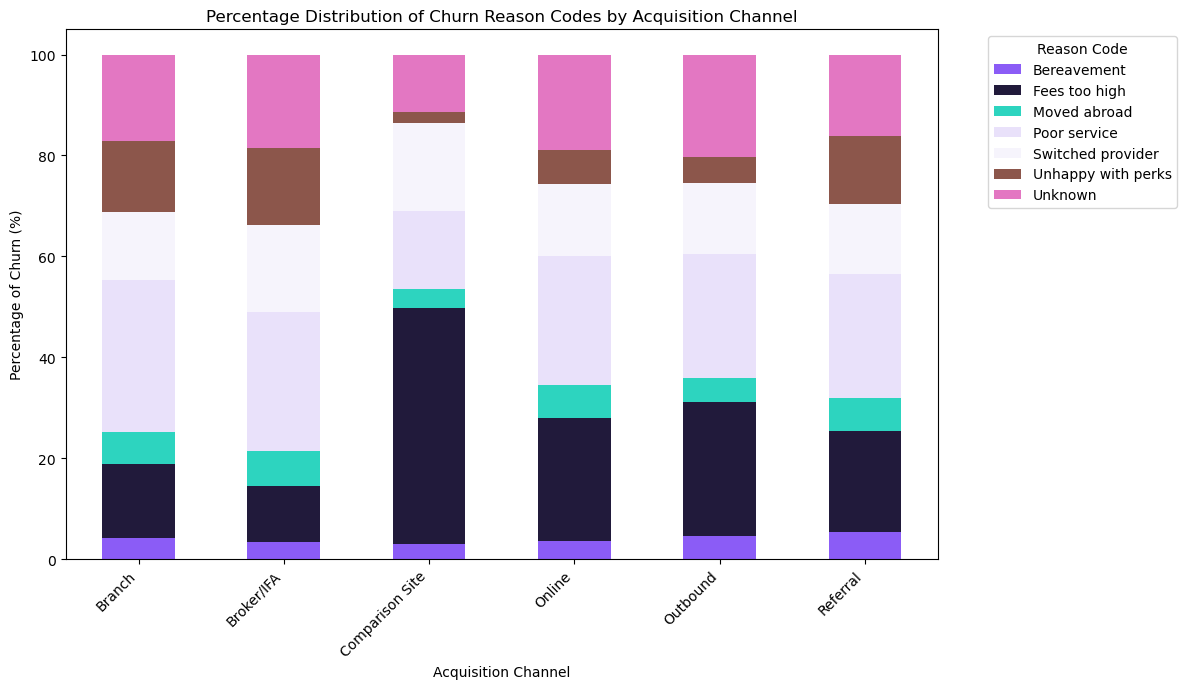

In [104]:
plt.figure(figsize=(12, 7))
# Define your custom colors here
custom_colors = ['#8B5CF6', '#211A3B', '#2DD4BF', '#E9E1FA', '#F6F4FC', '#8c564b', '#e377c2']
reason_code_distribution_percent.plot(kind='bar', stacked=True, figsize=(12, 7), color=custom_colors)
plt.title('Percentage Distribution of Churn Reason Codes by Acquisition Channel')
plt.xlabel('Acquisition Channel')
plt.ylabel('Percentage of Churn (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Reason Code', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Total marketing spend / share of marketing spend over time

In [5]:
# Total spend per month
total_spend = marketing.groupby('month')['spend_gbp'].sum().rename('total_spend')

# Spend per month per channel (pivoted into columns)
total_spend_channel = marketing.pivot_table(index='month', columns='channel', values='spend_gbp', aggfunc='sum')
total_spend_channel.columns = ['branch', 'broker', 'comp', 'online', 'out', 'refer']

# Combine into one dataframe
monthly_spend = total_spend.to_frame().join(total_spend_channel).reset_index()
monthly_spend.head()

,month,total_spend,branch,broker,comp,online,out,refer
0,2022-01,25202.0,7310.0,4014.0,3162.0,3945.0,4899.0,1872.0
1,2022-02,25260.0,7882.0,1989.0,3266.0,4231.0,5548.0,2344.0
2,2022-03,26444.0,6792.0,5159.0,2804.0,5394.0,4134.0,2161.0
3,2022-04,25805.0,9152.0,2358.0,2765.0,5239.0,4415.0,1876.0
4,2022-05,27488.0,7144.0,4637.0,3850.0,5145.0,4894.0,1818.0


In [6]:
# monthly_spend.to_csv("moneycraft_monthly_spend.csv", index=False)

In [4]:
# 1. Create a year column from the month string (extracting the first 4 characters)
marketing['year'] = marketing['month'].str[:4]

# 2. Total spend per year (matching your total_spend logic)
total_spend_year = marketing.groupby('year')['spend_gbp'].sum().rename('total_spend')

# 3. Spend per year per channel (matching your pivot_table logic, grouped by year)
total_spend_channel_year = marketing.pivot_table(index='year', columns='channel', values='spend_gbp', aggfunc='sum')
total_spend_channel_year.columns = ['branch', 'broker', 'comp', 'online', 'out', 'refer']

# 4. Combine into one annual dataframe
yearly_spend = total_spend_year.to_frame().join(total_spend_channel_year).reset_index()
yearly_spend

,year,total_spend,branch,broker,comp,online,out,refer
0,2022,347858.0,98703.0,52102.0,45351.0,64861.0,57854.0,28987.0
1,2023,451457.0,124181.0,65623.0,57546.0,89760.0,76932.0,37415.0
2,2024,576285.0,154683.0,77295.0,79509.0,114701.0,104478.0,45619.0


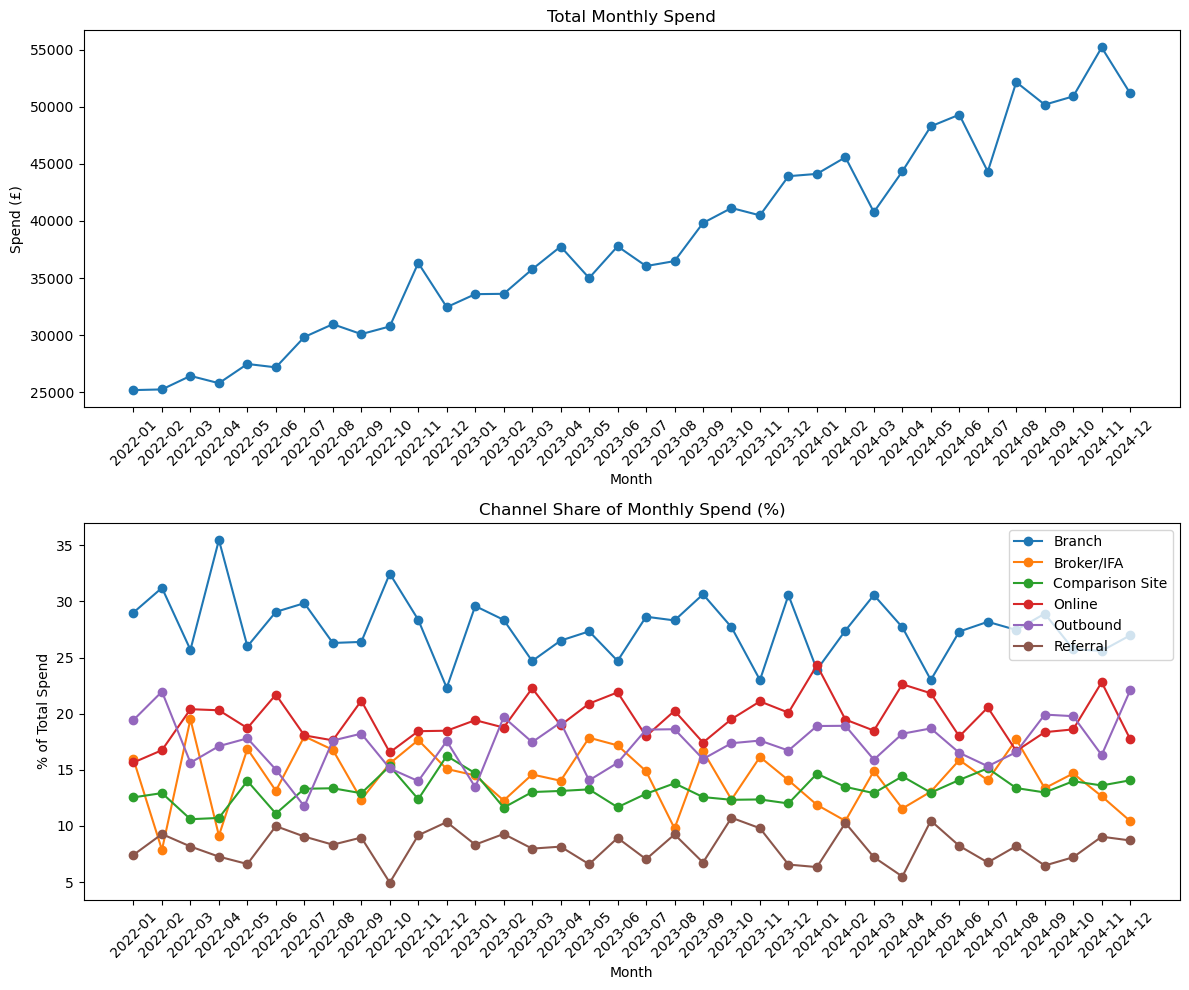

In [5]:
channels = ['branch', 'broker', 'comp', 'online', 'out', 'refer']

channel_map = {
    'branch': 'Branch',
    'broker': 'Broker/IFA',
    'comp': 'Comparison Site',
    'online': 'Online',
    'out': 'Outbound',
    'refer': 'Referral'
}

pct_df = monthly_spend[channels].div(monthly_spend['total_spend'], axis=0) * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Total monthly spend
axes[0].plot(monthly_spend['month'], monthly_spend['total_spend'], marker='o')
axes[0].set_title('Total Monthly Spend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Spend (£)')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: % spend per channel
for actual_col, display_name in channel_map.items():
    axes[1].plot(monthly_spend['month'], pct_df[actual_col], marker='o', label=display_name)

axes[1].set_title('Channel Share of Monthly Spend (%)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('% of Total Spend')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

## CAC

### Analysis

In [3]:
# Isolate the true acquisition month for each unique customer
cohorts = accounts.groupby('customer_id').agg(
    acquisition_month=('month', 'min'), # column 'acquisition_month', the first month associated with each customer
    acquisition_channel=('acquisition_channel', 'first') # select first 'acquisition_channel' as doesn't change over time
).reset_index() # reset index to keep customer id as a normal column
cohorts.head()

,customer_id,acquisition_month,acquisition_channel
0,1,2022-01,Comparison Site
1,2,2022-01,Online
2,3,2022-01,Branch
3,4,2022-01,Referral
4,5,2022-01,Comparison Site


In [4]:
# Aggregate total volume of new sign-ups per month per channel
acquisition_counts = cohorts.groupby(['acquisition_month', 'acquisition_channel']).size().reset_index(name='new_customers')
acquisition_counts.head()

,acquisition_month,acquisition_channel,new_customers
0,2022-01,Branch,49
1,2022-01,Broker/IFA,21
2,2022-01,Comparison Site,81
3,2022-01,Online,58
4,2022-01,Outbound,39


In [5]:
# Standardize column names for clean merging
marketing_copy = marketing.copy()
marketing_copy = marketing_copy.rename(columns={'channel': 'acquisition_channel', 'month': 'acquisition_month'})
marketing_copy.head()

,acquisition_month,acquisition_channel,spend_gbp
0,2022-01,Branch,7310.0
1,2022-01,Broker/IFA,4014.0
2,2022-01,Comparison Site,3162.0
3,2022-01,Online,3945.0
4,2022-01,Outbound,4899.0


In [6]:
# Merge spend data with acquisition numbers
cac_monthly = pd.merge(marketing_copy, acquisition_counts, on=['acquisition_month', 'acquisition_channel'], how='left')
cac_monthly.head()

,acquisition_month,acquisition_channel,spend_gbp,new_customers
0,2022-01,Branch,7310.0,49
1,2022-01,Broker/IFA,4014.0,21
2,2022-01,Comparison Site,3162.0,81
3,2022-01,Online,3945.0,58
4,2022-01,Outbound,4899.0,39


In [7]:
# Fill any NaN values if a channel had spend but zero acquisitions in a month
cac_monthly['new_customers'] = cac_monthly['new_customers'].fillna(0)

In [8]:
# Compute the Customer Acquisition Cost (CAC) - The price per customer for each channel, for each month
cac_monthly['cac_gbp'] = cac_monthly['spend_gbp'] / cac_monthly['new_customers']
cac_monthly.head()

,acquisition_month,acquisition_channel,spend_gbp,new_customers,cac_gbp
0,2022-01,Branch,7310.0,49,149.183673
1,2022-01,Broker/IFA,4014.0,21,191.142857
2,2022-01,Comparison Site,3162.0,81,39.037037
3,2022-01,Online,3945.0,58,68.017241
4,2022-01,Outbound,4899.0,39,125.615385


In [10]:
# cac_monthly.to_csv("moneycraft_cac_monthly.csv", index=False)

In [9]:
# Calculate total channel CAC by summing over time
channel_perf = cac_monthly.groupby('acquisition_channel').agg(
    total_spend=('spend_gbp', 'sum'),
    total_acquired=('new_customers', 'sum')
).reset_index()
channel_perf['total_channel_cac'] = channel_perf['total_spend'] / channel_perf['total_acquired']
channel_perf

,acquisition_channel,total_spend,total_acquired,total_channel_cac
0,Branch,377567.0,2481,152.183394
1,Broker/IFA,195020.0,979,199.203269
2,Comparison Site,182406.0,4584,39.791885
3,Online,269322.0,3851,69.935601
4,Outbound,239264.0,1962,121.949032
5,Referral,112021.0,1875,59.744533


### Insights

In [13]:
# Calculate company blended CAC (average CAC over all channels) as the baseline.
total_company_spend = channel_perf['total_spend'].sum()
total_company_acquired = channel_perf['total_acquired'].sum()

company_blended_cac = total_company_spend / total_company_acquired

# 
print(f"True Company Blended CAC: £{company_blended_cac:.2f}")
print("\n--- LIFETIME ACQUISITION METRICS BY CHANNEL ---")
print(channel_perf.to_string(index=False))

True Company Blended CAC: £87.44

--- LIFETIME ACQUISITION METRICS BY CHANNEL ---
acquisition_channel  total_spend  total_acquired  total_channel_cac
             Branch     377567.0            2481         152.183394
         Broker/IFA     195020.0             979         199.203269
    Comparison Site     182406.0            4584          39.791885
             Online     269322.0            3851          69.935601
           Outbound     239264.0            1962         121.949032
           Referral     112021.0            1875          59.744533


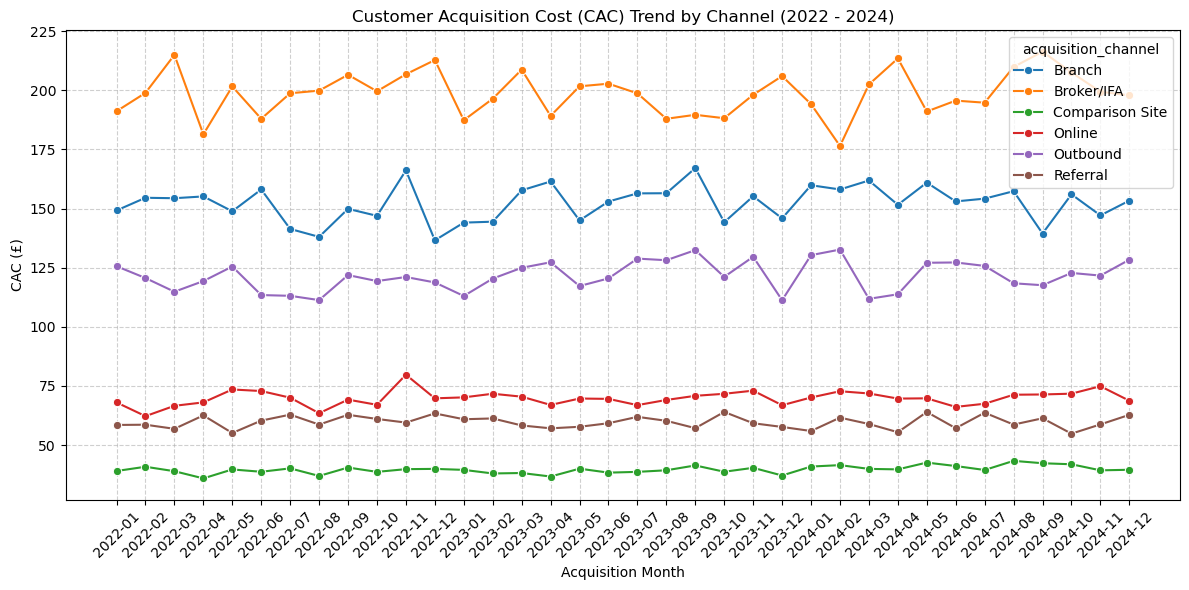

In [14]:
# 8. Plot CAC trends over time to identify efficiency drift
plt.figure(figsize=(12, 6))
sns.lineplot(data=cac_summary, x='acquisition_month', y='cac_gbp', hue='acquisition_channel', marker='o')
plt.title("Customer Acquisition Cost (CAC) Trend by Channel (2022 - 2024)")
plt.ylabel("CAC (£)")
plt.xlabel("Acquisition Month")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("cac_trends_over_time.png")
plt.show()

**CAC** - Customer Acquired Cost, the total spent on a marketing channel, divided by the number of customers acquired through that channel.

**NOTE:** Does not account for the lifetime/tier of each customer, for that we will incorporate **LTV**. (some channels may bring in higher paying customers, not all customers are created equally).

1. Comparison Site, Referral and Online have the lowest CAC and are below the company average CAC, therefore on average bring in the most customers for every £ spent marketting those channels. Outbound, Branch, Broker are much higher.

2. The CAC of each channel does not appear to vary noteably over the time period, assuming channels bring in roughly the same distribution of tiers over time, this means marketing efficiency has not decreased as the company has scaled. This suggests that we have not hit diminihing returns on our marketing channels and have not exhausted our core target audience, therefore we can confirm that the marketing team have developed a predictable and repeatable customer acquistion approach.

## LTV

### Analysis

In [27]:
# 2. Calculate true monthly Churn Rate and ARPU from the SCV ground truth
# Summing tenure_months gives us the exact total active months lived by customers in that channel
scv_metrics = scv.groupby('channel').agg(
    total_acquired_customers=('churned', 'count'),
    total_churned_customers=('churned', 'sum'),       # Uses the SCV boolean/integer churned flag
    total_tenure_months=('tenure_months', 'sum'),
    total_revenue_collected=('total_revenue', 'sum')
).reset_index()
scv_metrics.head()

,channel,total_acquired_customers,total_churned_customers,total_tenure_months,total_revenue_collected
0,Branch,2481,606,33277,551910
1,Broker/IFA,979,205,13583,264127
2,Comparison Site,4584,2370,42794,292049
3,Online,3851,1462,43906,490779
4,Outbound,1962,868,20298,187186


In [38]:
# Monthly Churn Rate = Total Churned / Total Active Customer-Months
scv_metrics['monthly_churn_rate'] = scv_metrics['total_churned_customers'] / scv_metrics['total_tenure_months']*100

In [33]:
# Monthly ARPU = Total Revenue Collected / Total Active Customer-Months
scv_metrics['monthly_arpu'] = scv_metrics['total_revenue_collected'] / scv_metrics['total_tenure_months']

In [34]:
# Calculate Forward-Looking LTV
# Formula: LTV = ARPU / Monthly Churn Rate
scv_metrics['forward_looking_ltv'] = scv_metrics['monthly_arpu'] / scv_metrics['monthly_churn_rate']

In [39]:
# 4. Merge with your existing channel_perf DataFrame to bring in your calculated CAC
# Merging on your channel column to prevent any recalculation of acquisition costs
channel_metrics = scv_metrics.merge(
    channel_perf, 
    left_on='channel', 
    right_on='acquisition_channel', 
    how='inner'
)
channel_metrics

,channel,total_acquired_customers,total_churned_customers,total_tenure_months,total_revenue_collected,monthly_churn_rate,monthly_arpu,forward_looking_ltv,acquisition_channel,total_spend,total_acquired,total_channel_cac
0,Branch,2481,606,33277,551910,1.821078,16.585329,910.742574,Branch,377567.0,2481,152.183394
1,Broker/IFA,979,205,13583,264127,1.509239,19.445410,1288.424390,Broker/IFA,195020.0,979,199.203269
2,Comparison Site,4584,2370,42794,292049,5.538160,6.824531,123.227426,Comparison Site,182406.0,4584,39.791885
3,Online,3851,1462,43906,490779,3.329841,11.177948,335.690150,Online,269322.0,3851,69.935601
4,Outbound,1962,868,20298,187186,4.276283,9.221894,215.652074,Outbound,239264.0,1962,121.949032
5,Referral,1875,446,25160,404091,1.772655,16.060851,906.033632,Referral,112021.0,1875,59.744533


### Insights

**LTV** - Lifetime Value, the total spent by a customer in their lifetime.

In [41]:
# 5. Calculate Final Comparative Evaluation Metrics
channel_metrics['LTV_to_CAC_Ratio'] = channel_metrics['forward_looking_ltv'] / channel_metrics['total_channel_cac']
# channel_metrics['Net_Forward_Value'] = channel_metrics['forward_looking_ltv'] - channel_metrics['total_channel_cac']

# Format output columns for clear presentation readability
output_cols = [
    'acquisition_channel', 'monthly_arpu', 'monthly_churn_rate', 
    'total_channel_cac', 'forward_looking_ltv', 'LTV_to_CAC_Ratio', 'Net_Forward_Value'
]

print("\n=== FINAL FORWARD-LOOKING LTV VS CAC ANALYSIS ===")
print(channel_metrics[output_cols].round(2).to_string(index=False))


=== FINAL FORWARD-LOOKING LTV VS CAC ANALYSIS ===
acquisition_channel  monthly_arpu  monthly_churn_rate  total_channel_cac  forward_looking_ltv  LTV_to_CAC_Ratio  Net_Forward_Value
             Branch         16.59                1.82             152.18               910.74              5.98             758.56
         Broker/IFA         19.45                1.51             199.20              1288.42              6.47            1089.22
    Comparison Site          6.82                5.54              39.79               123.23              3.10              83.44
             Online         11.18                3.33              69.94               335.69              4.80             265.75
           Outbound          9.22                4.28             121.95               215.65              1.77              93.70
           Referral         16.06                1.77              59.74               906.03             15.17             846.29


Customers who join through Broker/IFA, Branch, Referral spend considerably more than other channels on average. 

If we look at LTV:CAC, we obtain a fairly good proxy metric for ROI of each channel, we want channels with low CAC - low cost to acquire new customer, and high LTV - high spending customers.

1. **Referral** is the clear winner, we would therefore recommend increasing spending on Referral.

2. **Outbound** is the clear loser, we would therefore recommend decreasing spending on referral